# TP 2 - Classification : Préparation des données

## 1) Importer les librairies

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
 



## 2) Importer et visualiser le dataset, les colonnes et les valeurs uniques de Purchased

In [2]:
file_path = 'Social_Network_Ads.csv'
dataset = pd.read_csv(file_path)

print('visualisation:')
display(dataset.head())

print('\nColonnes :')
print(dataset.columns.tolist())

print('\nValeurs uniques de Purchased :')
print(dataset['Purchased'].unique())


visualisation:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0



Colonnes :
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

Valeurs uniques de Purchased :
[0 1]


## 3) Nombre de Purchased par Gender (Male/Female)

In [3]:
print(dataset.groupby('Gender')['Purchased'].value_counts())

Gender  Purchased
Female  0            127
        1             77
Male    0            130
        1             66
Name: count, dtype: int64


## 4) Specifier X et y avec iloc

In [4]:
#dataframe.iloc[:, column_index] to retrive colums (iloc[lingne(: means all),colums]) :4 4 doent count
X = dataset.iloc[:, 0:4]
y = dataset.iloc[:, 4]
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64


## 5) Gerer les donnees manquantes et les variables categoriques

In [5]:
print(dataset.isnull().sum()) # no null values


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [6]:
print(dataset.duplicated().sum()) # no dublicated values

0


In [7]:
dataset["Gender"].unique() #see if there is typos

array(['Male', 'Female'], dtype=object)

In [8]:

# change male female to 0 and 1 
encoder = OneHotEncoder()
transformed_data = encoder.fit_transform(dataset[['Gender']])


dataset[encoder.categories_[0]] = transformed_data.toarray()
dataset.drop('Gender', axis=1, inplace=True)
dataset.head()


,User ID,Age,EstimatedSalary,Purchased,Female,Male
0,15624510,19.0,19000.0,0,0.0,1.0
1,15810944,35.0,20000.0,0,0.0,1.0
2,15668575,26.0,43000.0,0,1.0,0.0
3,15603246,27.0,57000.0,0,1.0,0.0
4,15804002,19.0,76000.0,0,0.0,1.0


In [9]:
# new X
X = dataset[['Female', 'Male', 'Age', 'EstimatedSalary']]
print(X)


     Female  Male   Age  EstimatedSalary
0       0.0   1.0  19.0          19000.0
1       0.0   1.0  35.0          20000.0
2       1.0   0.0  26.0          43000.0
3       1.0   0.0  27.0          57000.0
4       0.0   1.0  19.0          76000.0
..      ...   ...   ...              ...
395     1.0   0.0  46.0          41000.0
396     0.0   1.0  51.0          23000.0
397     1.0   0.0  50.0          20000.0
398     0.0   1.0  36.0          33000.0
399     1.0   0.0  49.0          36000.0

[400 rows x 4 columns]


## 6) Diviser le dataset entre le Training set et le Test set

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, 
)

## 7) Feature Scaling (Normalisation/Standardisation)

In [11]:
#standarisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train = scaler.fit_transform(X_train)
scaled_test = scaler.transform(X_test)
scaled_df_train =pd.DataFrame(scaled_train, columns=X_train.columns)
scaled_df_test =pd.DataFrame(scaled_test, columns=X_test.columns)
print(scaled_df_test)
print(scaled_df_train)

      Female      Male       Age  EstimatedSalary
0   0.935414 -0.935414  0.370112         0.014273
1   0.935414 -0.935414  1.101798        -1.462260
2   0.935414 -0.935414  0.918877         1.815644
3   0.935414 -0.935414  1.559103         1.786113
4  -1.069045  1.069045 -0.361575         1.254561
..       ...       ...       ...              ...
95  0.935414 -0.935414 -0.178654        -0.576340
96 -1.069045  1.069045  0.918877        -0.842116
97 -1.069045  1.069045  1.010337        -1.226015
98  0.935414 -0.935414 -0.453036         1.284092
99  0.935414 -0.935414 -0.087193         0.043804

[100 rows x 4 columns]
       Female      Male       Age  EstimatedSalary
0   -1.069045  1.069045 -0.270114         0.102865
1    0.935414 -0.935414 -1.093262         0.427702
2    0.935414 -0.935414  0.827416        -0.546810
3    0.935414 -0.935414 -1.824949        -0.044788
4    0.935414 -0.935414 -0.087193        -0.221972
..        ...       ...       ...              ...
295  0.935414 -0.93

In [12]:
#normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_train = scaler.fit_transform(X_train)
normalized_test = scaler.transform(X_test)
normalized_df_train =pd.DataFrame(normalized_train, columns=X_train.columns)
normalized_df_test =pd.DataFrame(normalized_test, columns=X_test.columns)
print(normalized_df_test)
print(normalized_df_train)

    Female  Male       Age  EstimatedSalary
0      1.0   0.0  0.571429         0.407407
1      1.0   0.0  0.761905         0.037037
2      1.0   0.0  0.714286         0.859259
3      1.0   0.0  0.880952         0.851852
4      0.0   1.0  0.380952         0.718519
..     ...   ...       ...              ...
95     1.0   0.0  0.428571         0.259259
96     0.0   1.0  0.714286         0.192593
97     0.0   1.0  0.738095         0.096296
98     1.0   0.0  0.357143         0.725926
99     1.0   0.0  0.452381         0.414815

[100 rows x 4 columns]
     Female  Male       Age  EstimatedSalary
0       0.0   1.0  0.404762         0.429630
1       1.0   0.0  0.190476         0.511111
2       1.0   0.0  0.690476         0.266667
3       1.0   0.0  0.000000         0.392593
4       1.0   0.0  0.452381         0.348148
..      ...   ...       ...              ...
295     1.0   0.0  0.714286         0.111111
296     0.0   1.0  0.738095         0.540741
297     1.0   0.0  0.809524         0.17037

## 8) le modèle de Régression Logistique

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 9) Faire les nouvelles prédictions sur X_test

In [14]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

## 10) la matrice de confusion  

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[61,  5],
       [11, 23]])

## 11) L’accuracy, La précision score, le recall et le F1_score

In [16]:
f1 = f1_score(y_test, y_pred)
f"f1 score: {round(f1,2)}"

'f1 score: 0.74'

In [17]:
precision = precision_score(y_test, y_pred)
f"Precision: {round(precision,2)}"

'Precision: 0.82'

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.84


In [19]:
recall = recall_score(y_test, y_pred)
f"Recall: {round(recall,2)}"

'Recall: 0.68'

## 12) Afficher la courbe ROC

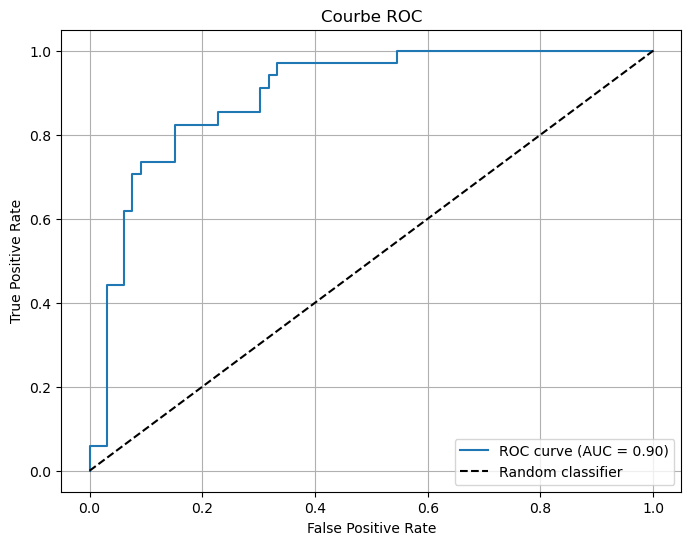

In [20]:
import matplotlib.pyplot as plt

y_score = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

## 13) Validation croisée (cv=5)

In [21]:
from sklearn.model_selection import cross_val_score
# On utilise le modèle déjà entraîné (LogisticRegression)
cross_val_scores = cross_val_score(model, X, y, cv=5)
print("Scores de validation croisée:", cross_val_scores)
print("Score moyen:", round(cross_val_scores.mean(), 2))

Scores de validation croisée: [0.7    0.9625 0.9375 0.8125 0.7   ]
Score moyen: 0.82


## 14) Hyperparameter Tuning (GridSearchCV)

In [22]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 0.5, 1, 2, 3, 4], 'solver': ['liblinear', 'lbfgs']}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X, y)
print("Best params:", grid.best_params_)
print("Best score:", round(grid.best_score_, 2))

Best params: {'C': 0.1, 'solver': 'lbfgs'}
Best score: 0.83


## 15) Mesures accuracy, precision, recall, F1 (après tuning)

In [23]:
from sklearn.metrics import classification_report
# Utiliser le meilleur modèle trouvé par GridSearchCV
y_pred_grid = grid.predict(X_test)
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        66
           1       0.82      0.68      0.74        34

    accuracy                           0.84       100
   macro avg       0.83      0.80      0.81       100
weighted avg       0.84      0.84      0.84       100



## 16) RandomizedSearchCV avec distribution uniforme

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
C = uniform(loc=0, scale=4)
parameters_2 = {"C": C}
cv_random = RandomizedSearchCV(LogisticRegression(max_iter=1000), parameters_2, n_iter=10, cv=5, random_state=42)
cv_random.fit(X, y)

,estimator,LogisticRegre...max_iter=1000)
,param_distributions,{'C': <scipy.stats....x7d3872eac830>}
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 17) Résultats RandomizedSearchCV : best_params et best_score

In [25]:
print("Best params:", cv_random.best_params_)
print("Best score:", round(cv_random.best_score_, 2))

Best params: {'C': np.float64(0.6240745617697461)}
Best score: 0.82


## 18) Visualisation des résultats (matrice de confusion et courbe ROC pour le meilleur modèle)

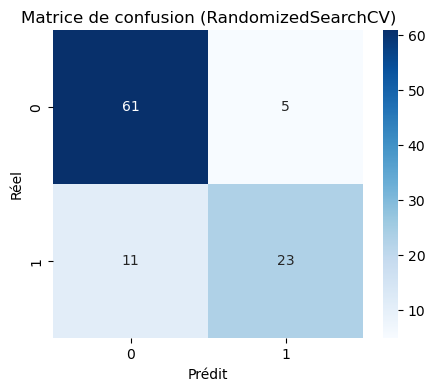

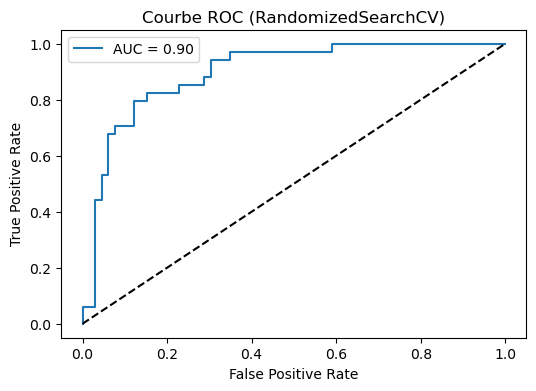

In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Prédictions avec le meilleur modèle de RandomizedSearchCV
y_pred_random = cv_random.predict(X_test)
cm_random = confusion_matrix(y_test, y_pred_random)

plt.figure(figsize=(5,4))
sns.heatmap(cm_random, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (RandomizedSearchCV)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Courbe ROC
proba_random = cv_random.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_random)
auc_score = roc_auc_score(y_test, proba_random)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC (RandomizedSearchCV)')
plt.legend()
plt.show()

## 19) Intercept et coefficients du meilleur modèle

In [27]:
print("Intercept:", cv_random.best_estimator_.intercept_)
print("Coefficients:", cv_random.best_estimator_.coef_)

Intercept: [-12.58771407]
Coefficients: [[-1.55125527e-01  1.55125530e-01  2.36397642e-01  3.63645770e-05]]


# ❖ Comparaison des modèles

## 1) Modèles alternatifs : KNN, Decision Tree, Random Forest, Naive Bayes, SVM

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'f1': f1}
    print(f"{name} - Accuracy: {round(acc,2)}, F1: {round(f1,2)}")

KNN - Accuracy: 0.77, F1: 0.65
Decision Tree - Accuracy: 0.87, F1: 0.81
Random Forest - Accuracy: 0.89, F1: 0.84
Naive Bayes - Accuracy: 0.88, F1: 0.82
SVM - Accuracy: 0.75, F1: 0.53


## 2) Interprétation et comparaison des résultats

# On compare les scores accuracy et F1 pour chaque modèle. Le meilleur modèle est celui qui a les scores les plus élevés. On peut aussi regarder le compromis entre précision et rappel selon le contexte.